CDC Diabetes Health Indicators

[Dataset](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators)

# Installing Pre-Requisites

In [2]:
!pip install ucimlrepo
!pip install imblearn
!pip install xgboost

# DataSet Preparation

## Descriptive Statistics

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier

In [4]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df= pd.concat([X, y], axis=1)
# variable information
#print in tabular fashion
display(cdc_diabetes_health_indicators.variables)

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,Patient ID,None,no
1,Diabetes_binary,Target,Binary,None,0 = no diabetes 1 = prediabetes or diabetes,None,no
2,HighBP,Feature,Binary,None,0 = no high BP 1 = high BP,None,no
3,HighChol,Feature,Binary,None,0 = no high cholesterol 1 = high cholesterol,None,no
4,CholCheck,Feature,Binary,None,0 = no cholesterol check in 5 years 1 = yes ch...,None,no
5,BMI,Feature,Integer,None,Body Mass Index,None,no
6,Smoker,Feature,Binary,None,Have you smoked at least 100 cigarettes in you...,None,no
7,Stroke,Feature,Binary,None,(Ever told) you had a stroke. 0 = no 1 = yes,None,no
8,HeartDiseaseorAttack,Feature,Binary,None,coronary heart disease (CHD) or myocardial inf...,None,no
9,PhysActivity,Feature,Binary,None,physical activity in past 30 days - not includ...,None,no


In [5]:
# Descriptive Statistics
print(df.head())

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  NoDocbcCost  GenHlth  MentHlth  \
0             0       0        1  ...            0        5        18   
1             1       0        0  ...            1        3         0   
2             0       1        0  ...            1        5        30   
3             1       1        1  ...            0        2         0   
4             1       1        1  ...            0        2         3   

   PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary  
0        15         1    0  

In [6]:
df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


##**Data Summary**

Based on the descriptive statistics of dataset, below are findings.

*   There are 253680 rows in dataset.
*   Dataset seems to be highly imbalanced based on mean of Diabetes_binary feature which is 0.13.




##Data Pre-processing / Cleaning

In [7]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64


There are no missing values in database.

##Duplicates Processing

In [8]:

# Check for duplicates
duplicates_before_removal = df.duplicated()
print("Number of duplicate rows:", duplicates_before_removal.sum())
print("Number of rows before duplicate removal:", len(df))

Number of duplicate rows: 24206
Number of rows before duplicate removal: 253680


**Remove Duplicates**

In [9]:
# emove duplicates
df = df.drop_duplicates()
#print rows after removal of duplicates
print("Number of rows after removing duplicates:", len(df))

Number of rows after removing duplicates: 229474


# Exploratory Data Analysis


##Univariate Analysis

Use histograms and box plots to understand the distribution of numerical features and count plots for categorical features.


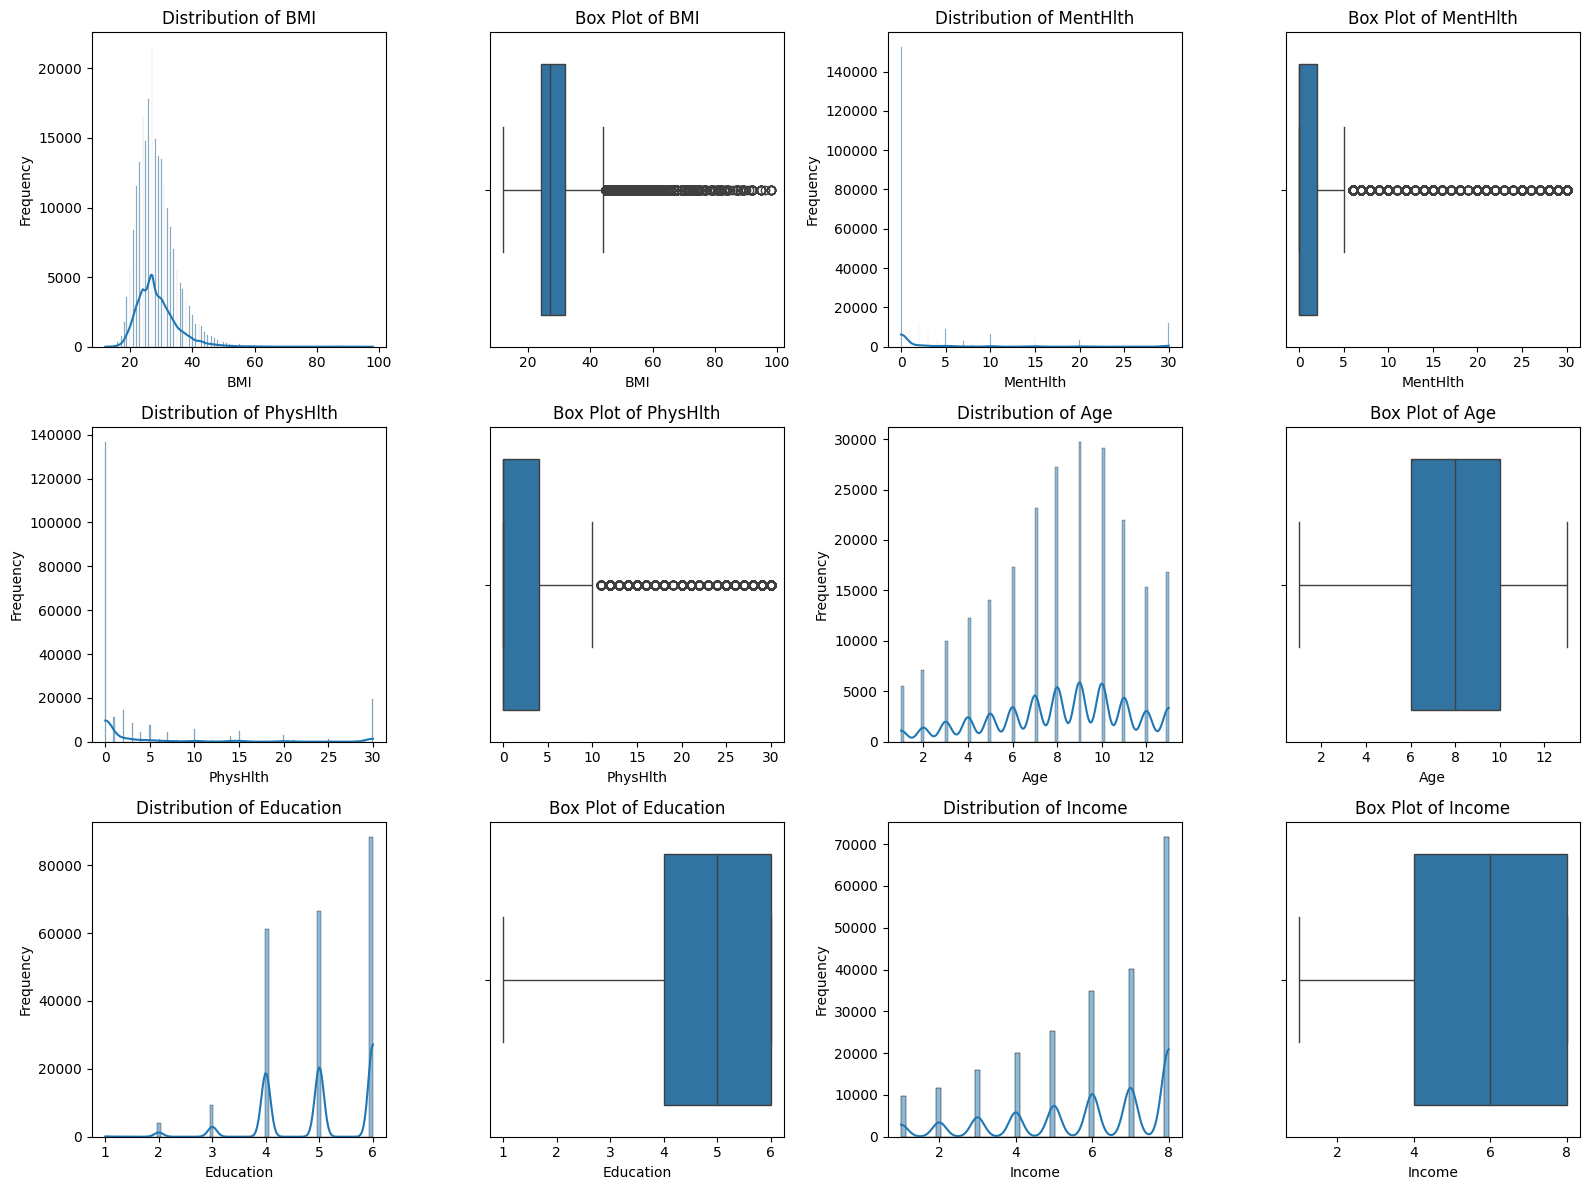

In [10]:
#exploratory data analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

# Determine the number of rows and columns for subplots
n_cols = 4
n_rows = (len(numerical_cols) * 2 + n_cols - 1) // n_cols # Two plots per column (hist and box)

# Histograms and Box plots for numerical columns side by side
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4)) # Adjusted figure size

axes = axes.flatten() # Flatten the axes array for easy iteration

for i, col in enumerate(numerical_cols):
    # Plot histogram
    sns.histplot(data=df, x=col, kde=True, ax=axes[i*2])
    axes[i*2].set_title(f'Distribution of {col}')
    axes[i*2].set_xlabel(col)
    axes[i*2].set_ylabel('Frequency')

    # Plot box plot
    sns.boxplot(data=df, x=col, ax=axes[i*2+1])
    axes[i*2+1].set_title(f'Box Plot of {col}')
    axes[i*2+1].set_xlabel(col)


# Hide any unused subplots
for j in range(len(numerical_cols) * 2, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

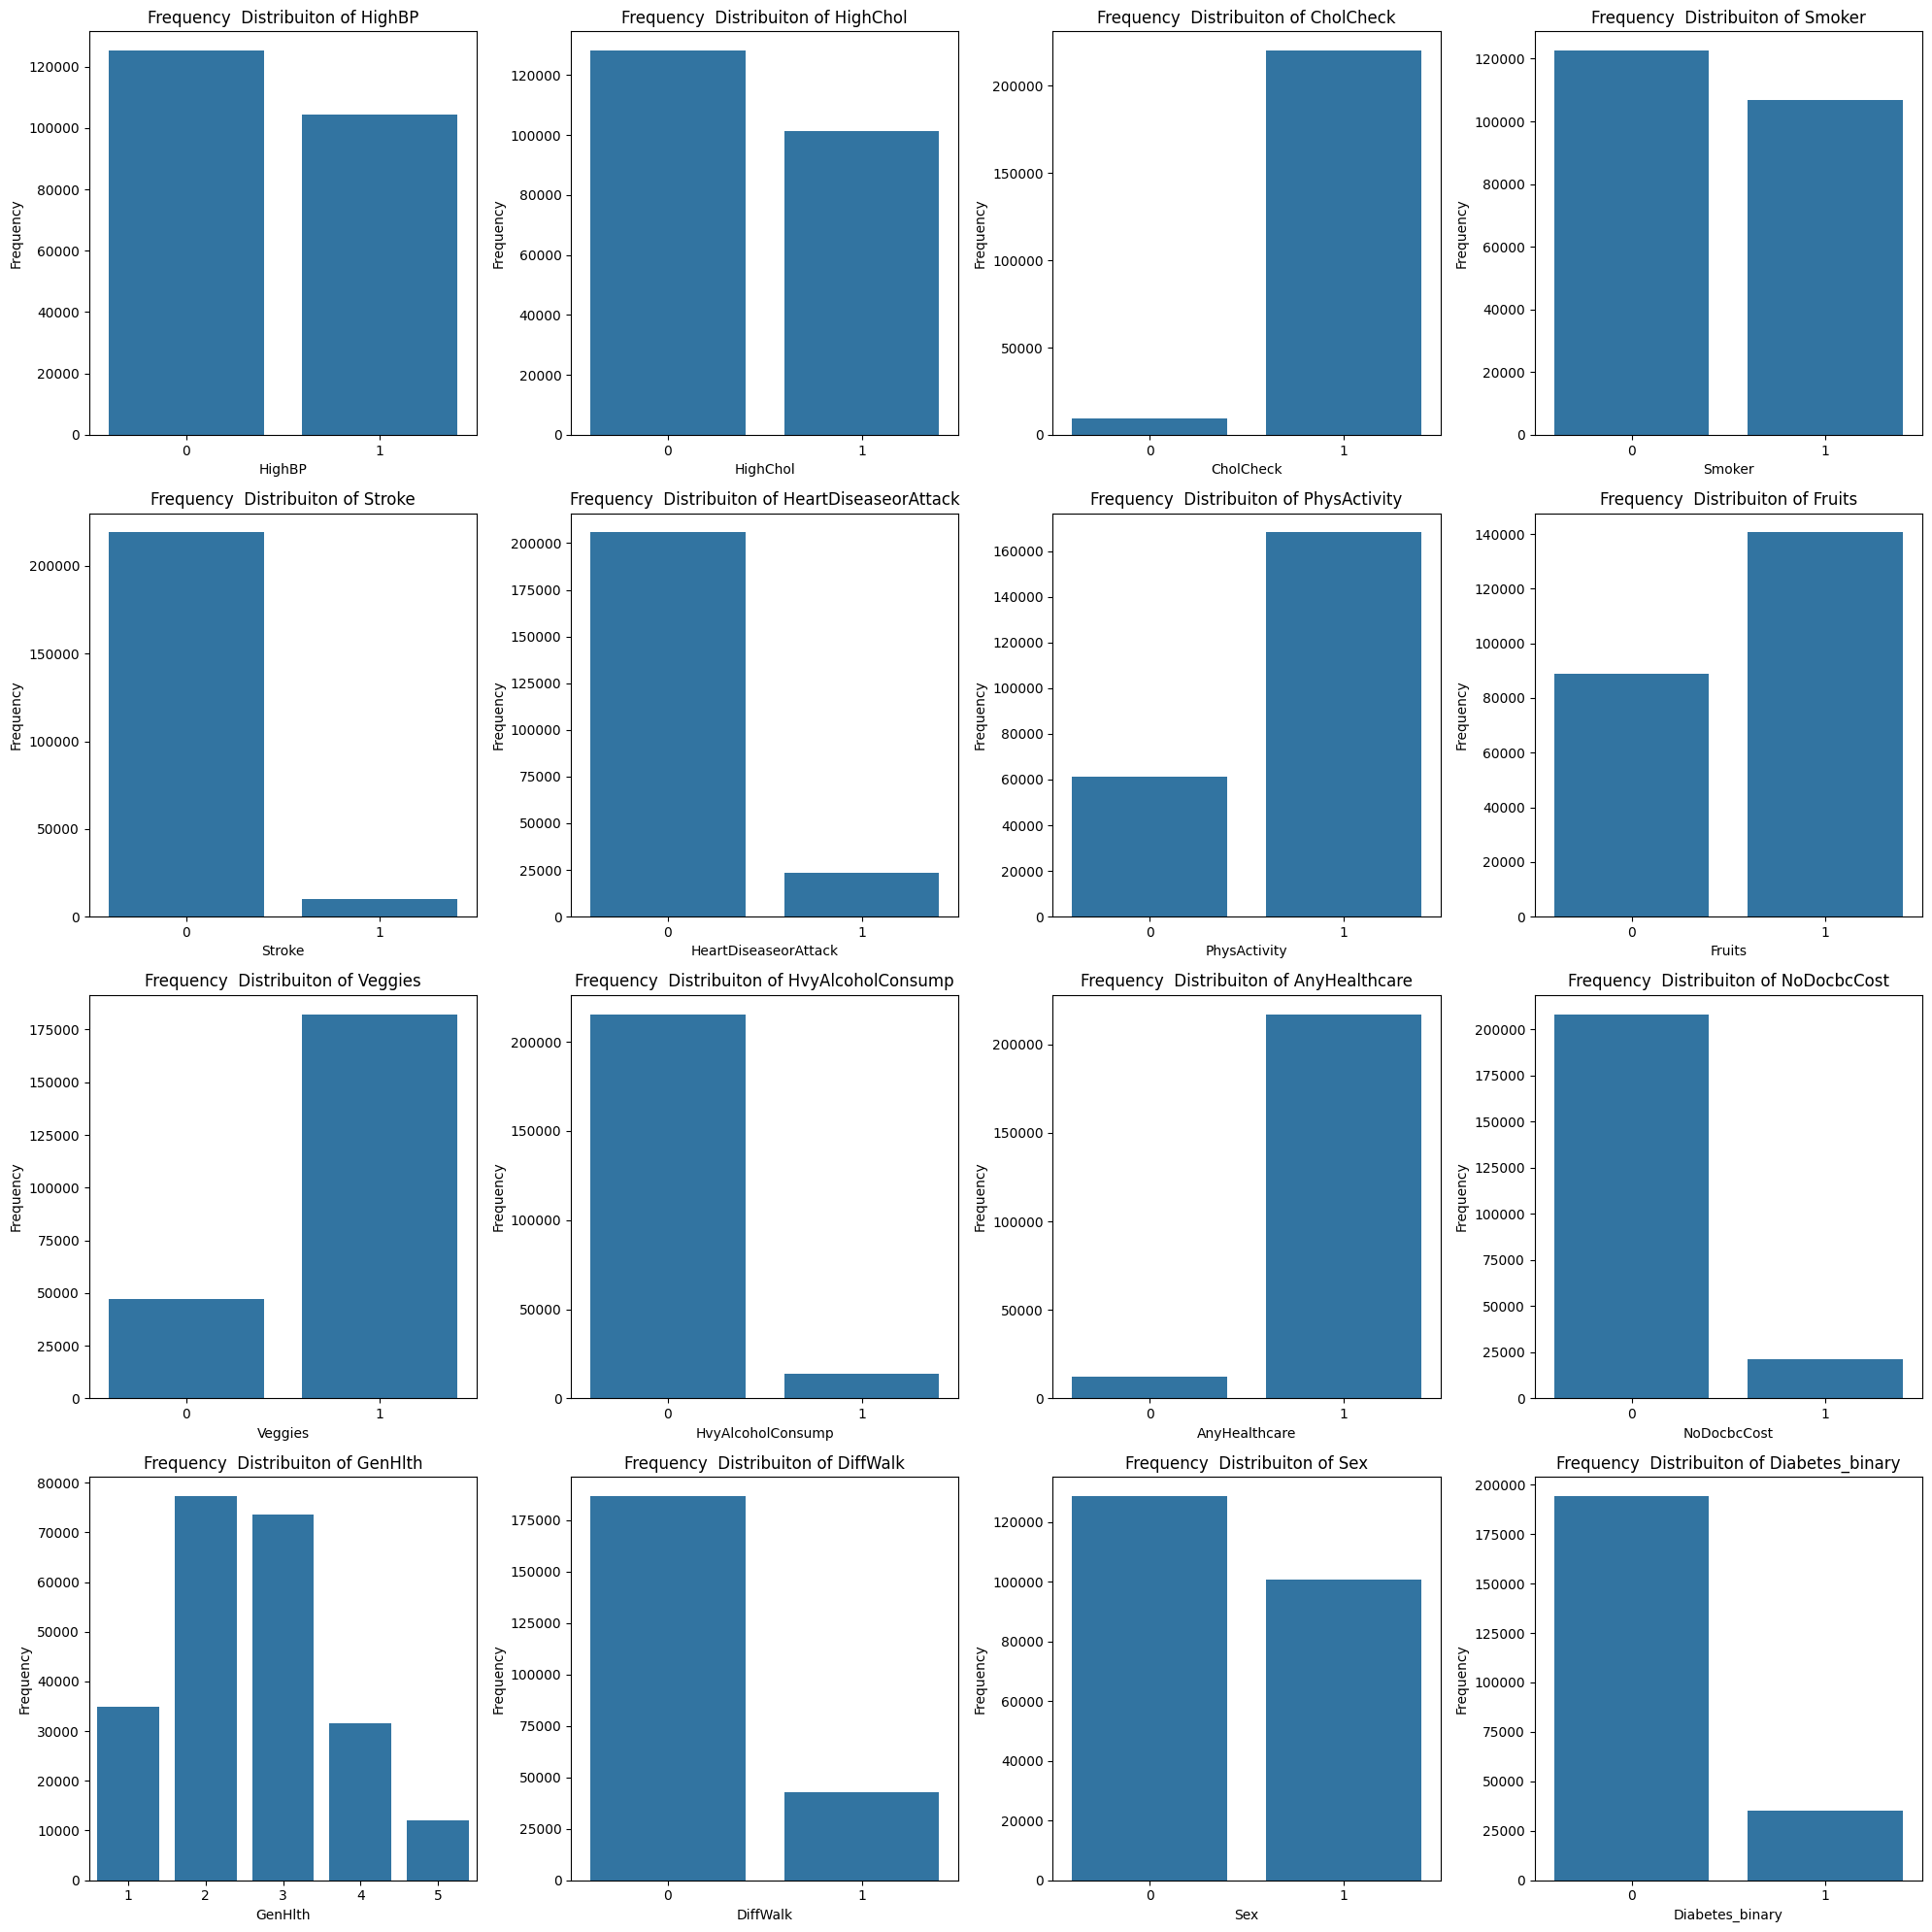

In [11]:
categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                     'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                     'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex','Diabetes_binary']

# Count plots for categorical columns with reduced size in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Frequency  Distribuiton of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Bivariate Analysis



### Visualization

Visualize the distribution of features for each class in the target variable to understand how features differ between diabetic and non-diabetic individuals.

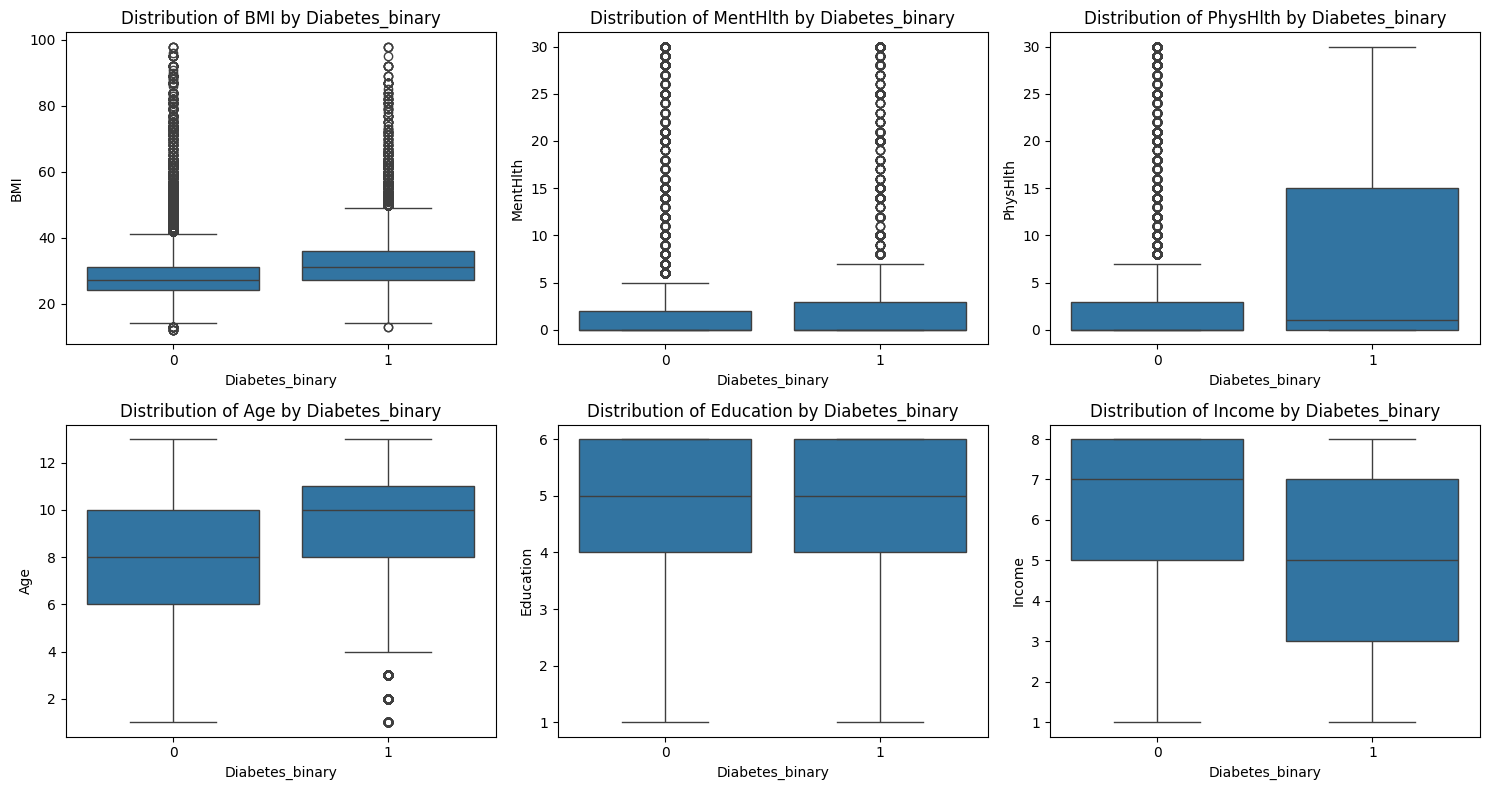

In [12]:

numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


# Box plots for numerical columns by Diabetes_binary
fig, axes = plt.subplots(2, 3, figsize=(15, 8)) # Adjusted to 2 rows and 3 columns for 6 plots
axes = axes.flatten() # Flatten the 2x3 array of axes to easily iterate

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Diabetes_binary', y=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Diabetes_binary')
    axes[i].set_xlabel('Diabetes_binary')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()




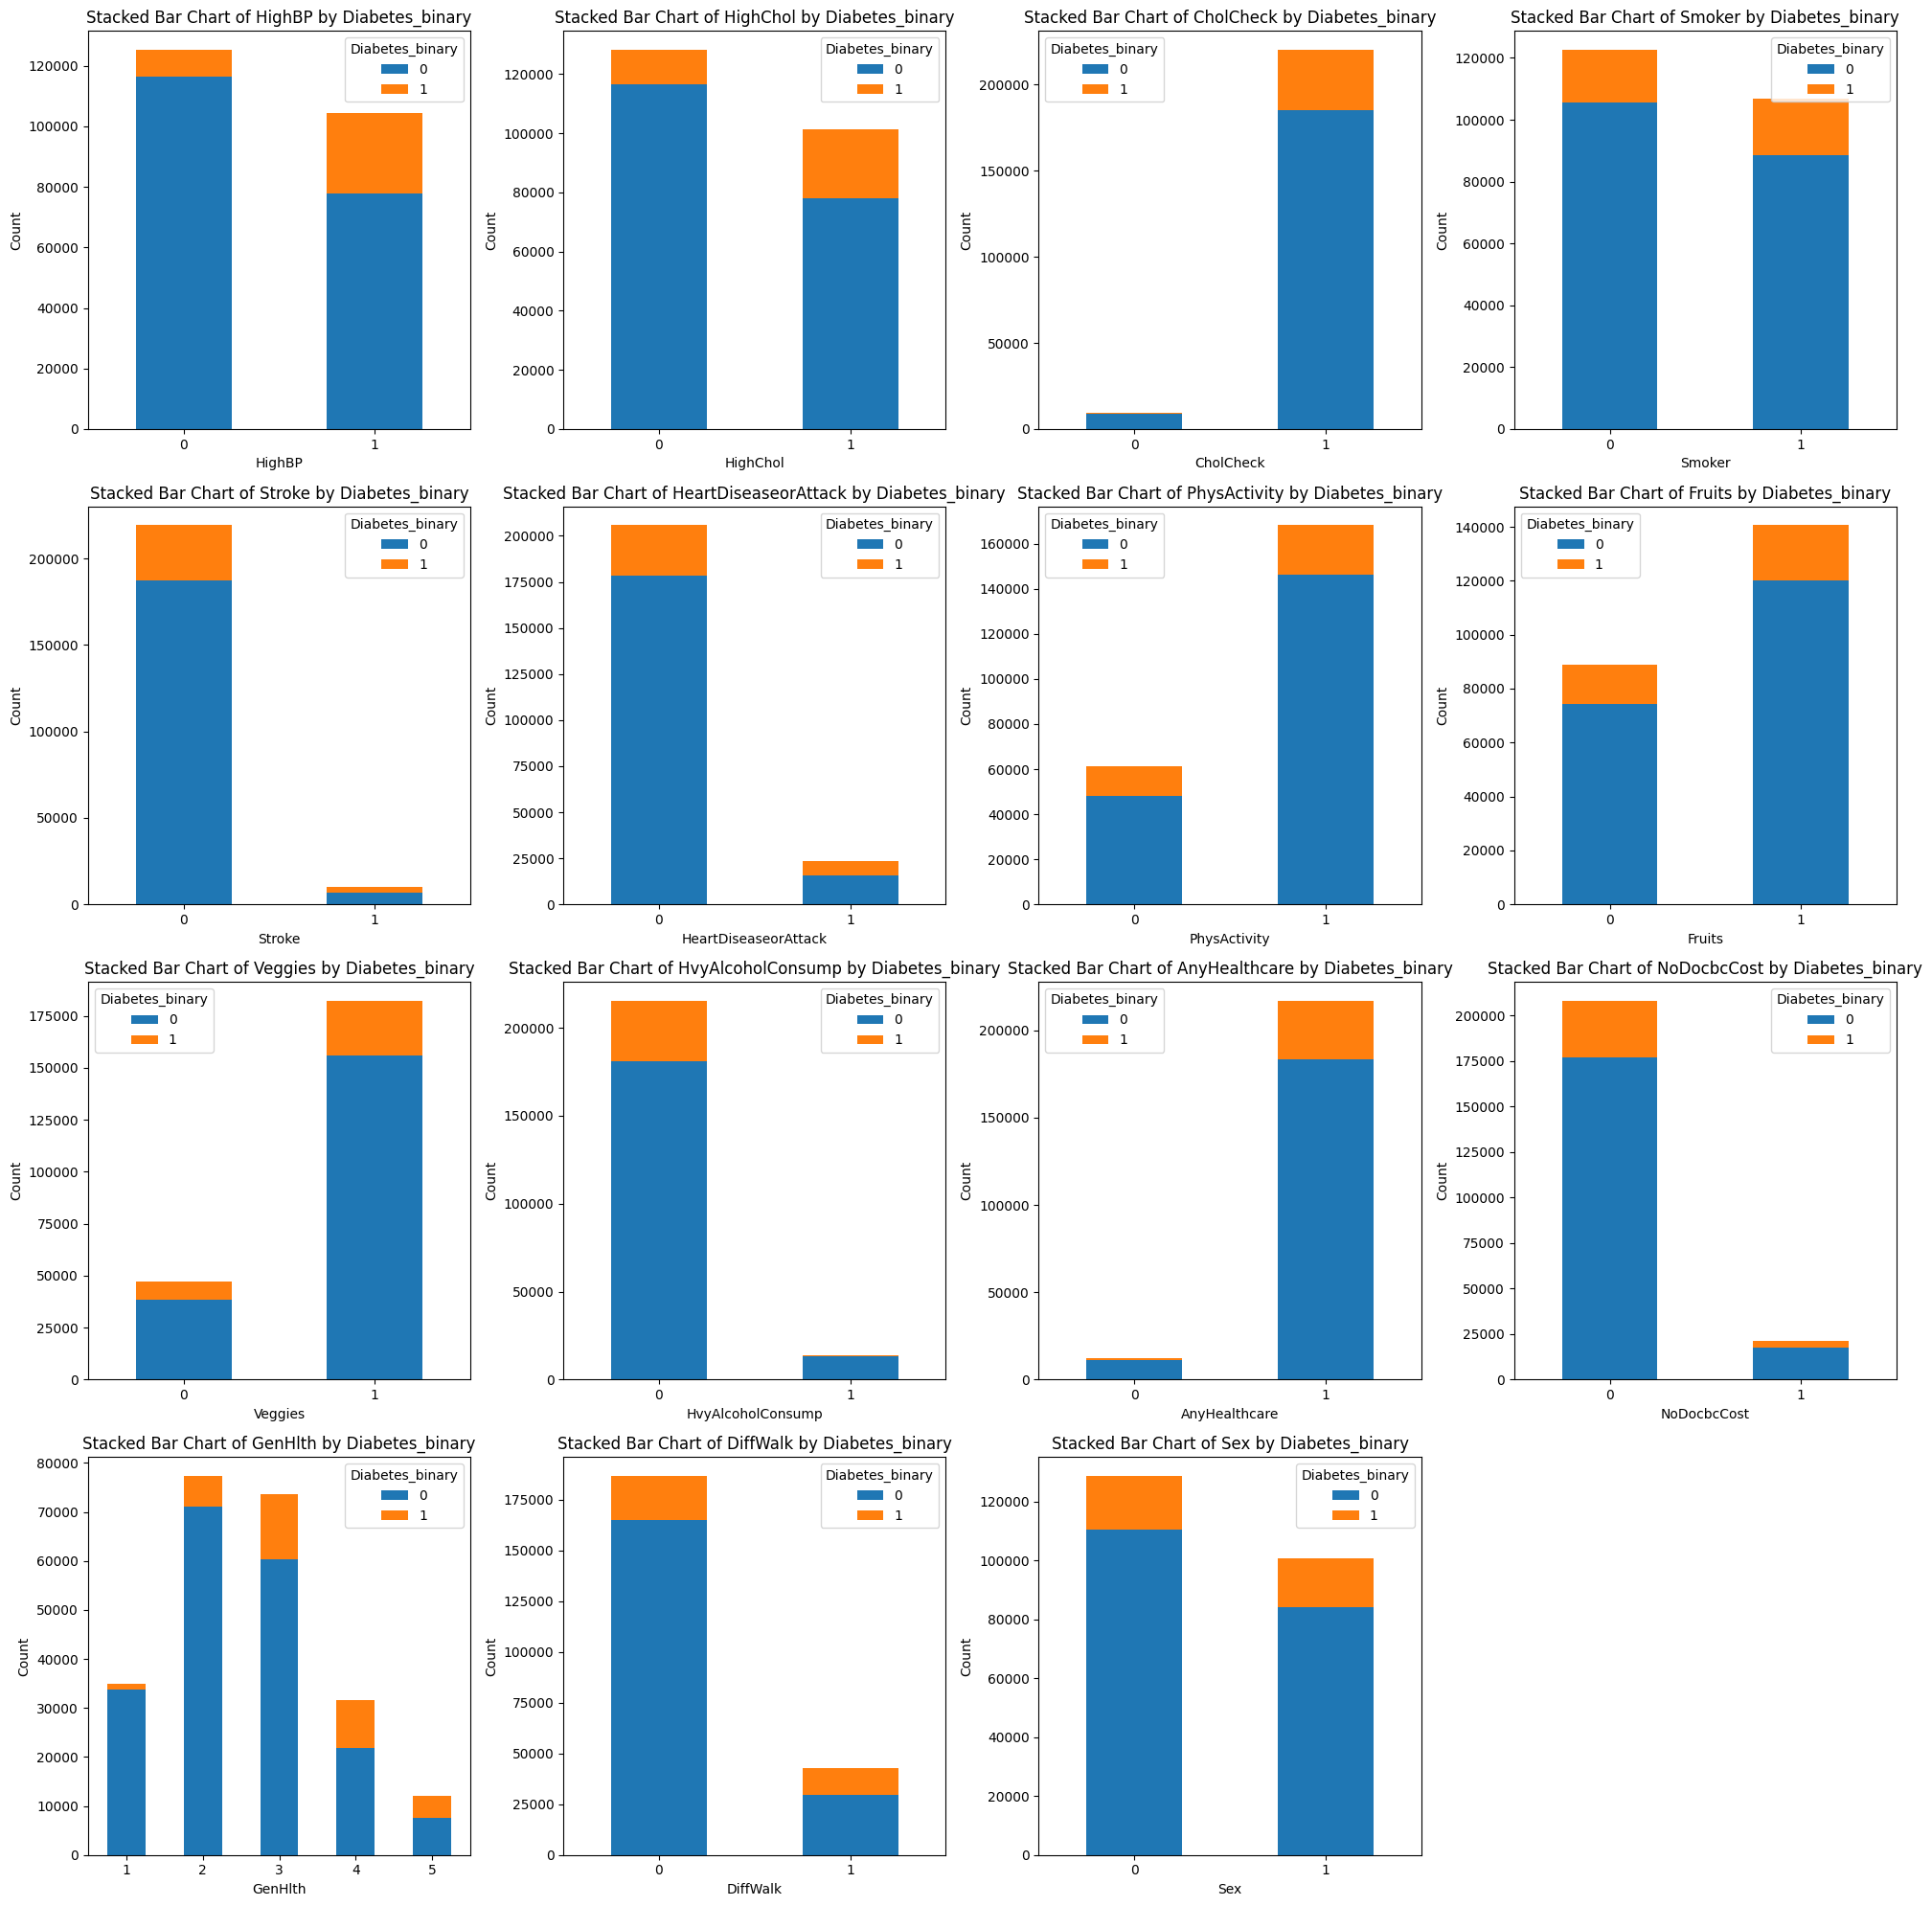

In [13]:
categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                     'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                     'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex'] # Removed 'Diabetes_binary' from categorical_cols


# Count plots for categorical columns by Diabetes_binary in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(20, 20)) # Changed to 4x4 grid for 16 plots
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Create a crosstab for stacked bar chart
    crosstab = pd.crosstab(df[col], df['Diabetes_binary'])
    crosstab.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'Stacked Bar Chart of {col} by Diabetes_binary')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0) # Rotate x-axis labels if needed


# Hide any unused subplots (although with 15 plots and 16 axes, there will be one unused)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Visualize pairwise plots between BMI, Age, Income


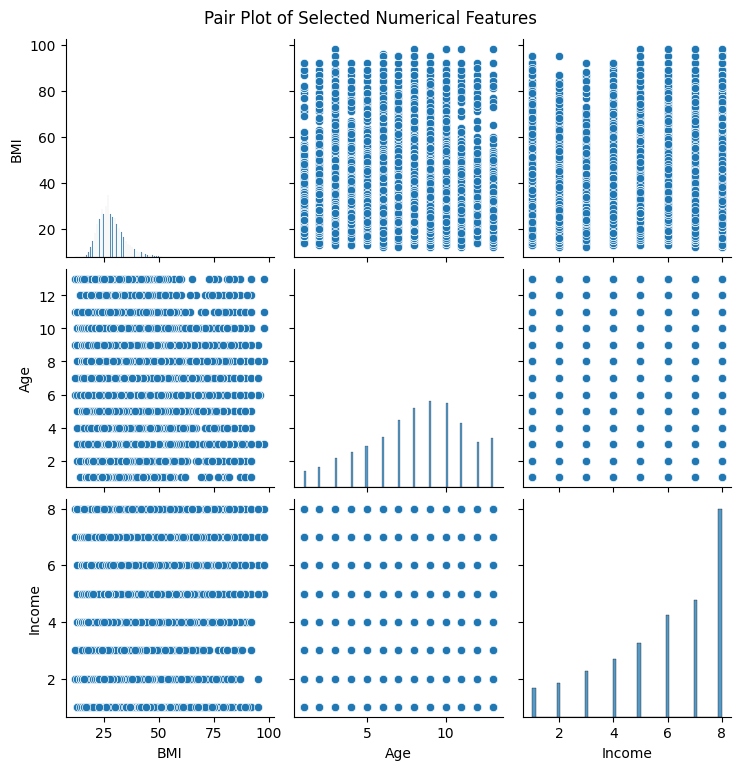

In [14]:
# Generate pair plots for a subset of numerical columns to visualize pairwise relationships
subset_numerical_cols = ['BMI', 'Age', 'Income'] # Selecting a smaller subset for clarity
sns.pairplot(df[subset_numerical_cols])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

Based on the pair plots generated above, there is no strong linear relationship between these variables Age, BMI and Income.

### Correlation analysis

Scatter plots, heatmaps, and pair plots to explore correlations and relationships between different variables.


####HeatMaps

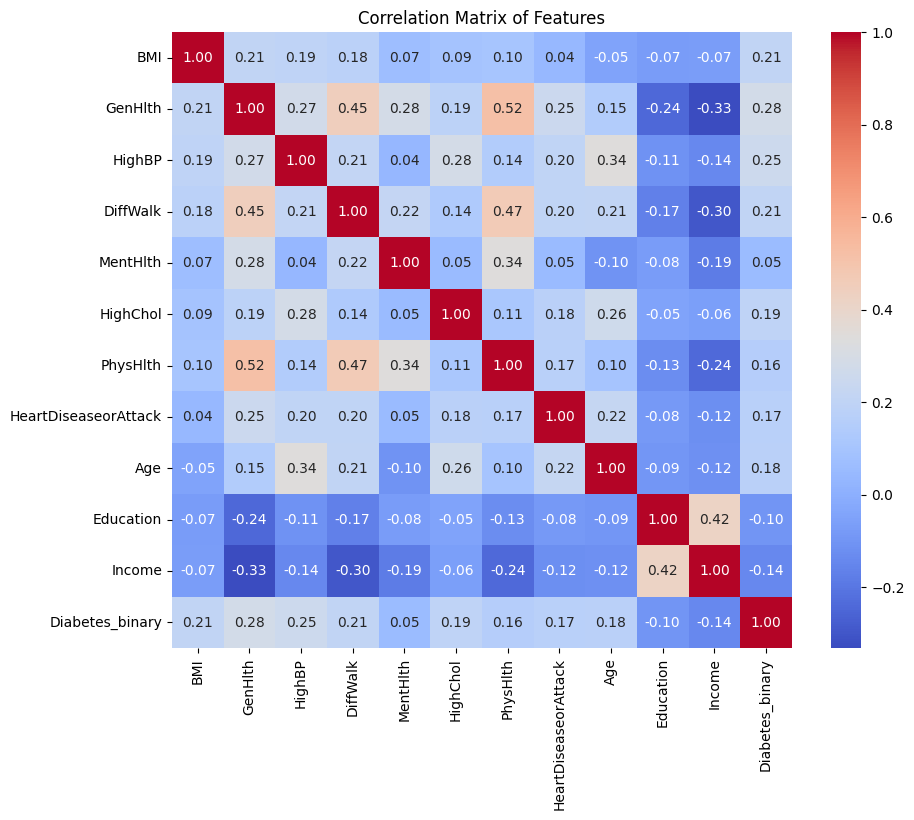

In [15]:
# Create a correlation matrix of the numerical columns
numerical_cols = ['BMI','GenHlth','HighBP','DiffWalk', 'MentHlth','HighChol', 'PhysHlth','HeartDiseaseorAttack', 'Age', 'Education', 'Income','Diabetes_binary']
correlation_matrix = df[numerical_cols].corr()

# Generate a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()



Heatmap shows the linear relationship between some variables BMI, Physical Health, Age, Education, Income. There is also strong multicollinearity in the dataset for eg. Physical Health and MentalHealth, Age and HighBP, Age and HeartDiseaseorAttack.

####Correlation Matrix

Correlation with Diabetes_binary:
Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


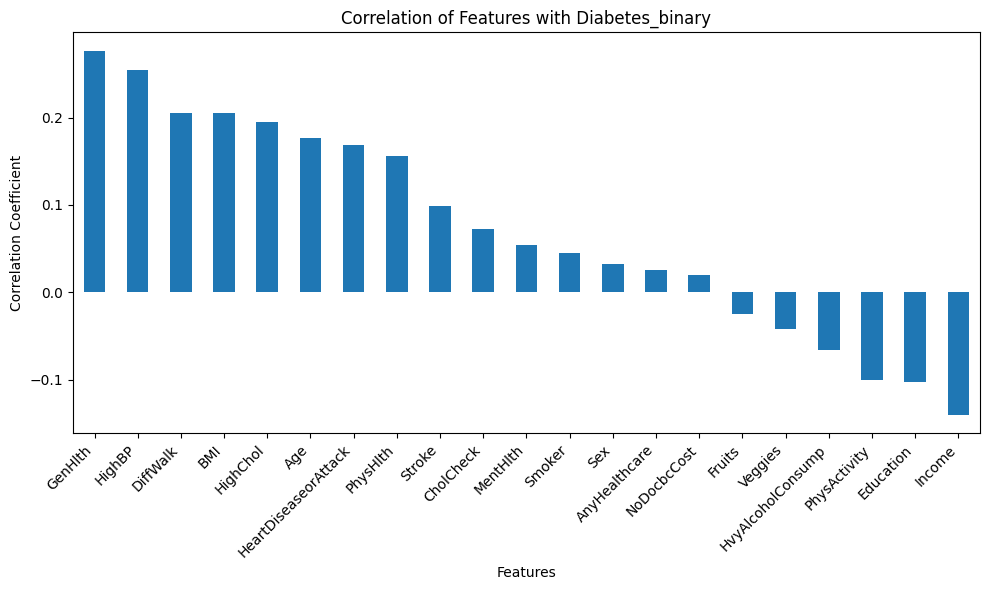

In [16]:
# Calculate the correlation matrix for the combined dataframe
correlation_matrix_combined = df.corr()

# Get the correlations with the 'Diabetes_binary' column
correlation_with_diabetes = correlation_matrix_combined['Diabetes_binary'].sort_values(ascending=False)

# Display the correlations
print("Correlation with Diabetes_binary:")
print(correlation_with_diabetes)

# Optional: Visualize the correlations with a bar plot
plt.figure(figsize=(10, 6))
correlation_with_diabetes.drop('Diabetes_binary').plot(kind='bar') # Drop the self-correlation
plt.title('Correlation of Features with Diabetes_binary')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##MultiVariate Analysis

### Mutual Information

Apply Mutual Information to identify the features with the highest relevance to the target variable.

Mutual Information Scores:
HighBP                  0.053140
GenHlth                 0.052544
PhysActivity            0.052416
AnyHealthcare           0.050609
CholCheck               0.048799
Fruits                  0.042253
Veggies                 0.042183
HighChol                0.040654
BMI                     0.030828
Sex                     0.025712
Smoker                  0.024667
Age                     0.023585
Education               0.023357
DiffWalk                0.022721
Income                  0.021443
HeartDiseaseorAttack    0.014241
PhysHlth                0.014222
Stroke                  0.004306
MentHlth                0.004185
HvyAlcoholConsump       0.002746
NoDocbcCost             0.000245
dtype: float64


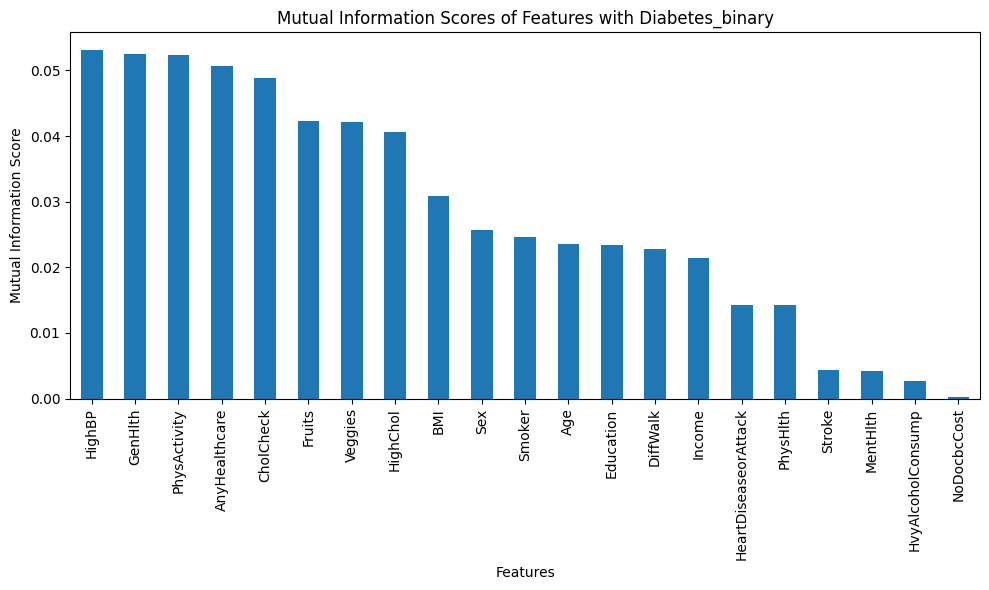

In [17]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import pandas as pd

# Calculate mutual information between each feature and the target
mutual_info_scores = mutual_info_classif(X, y.values.ravel(), random_state=42)

# Create a pandas Series for easier visualization
mutual_info_series = pd.Series(mutual_info_scores, index=X.columns)

# Sort the scores for better readability
sorted_mutual_info = mutual_info_series.sort_values(ascending=False)

# Print the mutual information scores
print("Mutual Information Scores:")
print(sorted_mutual_info)

# Visualize the mutual information scores
plt.figure(figsize=(10, 6))
sorted_mutual_info.plot(kind='bar')
plt.title('Mutual Information Scores of Features with Diabetes_binary')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

###Binomial Regression

In [18]:
import statsmodels.api as sm

# Add a constant to the features (X) for the intercept term
X_with_constant = sm.add_constant(X)

# Fit the logistic regression model with Logit link since its Binomial usecase
logit_model = sm.Logit(y, X_with_constant)
result = logit_model.fit()

# Print the model summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.319662
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        Diabetes_binary   No. Observations:               253680
Model:                          Logit   Df Residuals:                   253658
Method:                           MLE   Df Model:                           21
Date:                Wed, 15 Oct 2025   Pseudo R-squ.:                  0.2083
Time:                        20:45:13   Log-Likelihood:                -81092.
converged:                       True   LL-Null:                   -1.0242e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -7.8362      0.094    -83.760      0.000      -8.020      -7.653

In [19]:
# import statsmodels.api as sm
# import pandas as pd

# # Assuming 'df' is your DataFrame with the original features and target
# # Create interaction terms (example: interaction between HighBP and HighChol)
# df['HighBP_HighChol_Interaction'] = df['HighBP'] * df['HighChol']
# df['BMI_GenHlth_Interaction'] = df['BMI'] * df['GenHlth']
# df['Age_HighBP_Interaction'] = df['Age'] * df['HighBP']


# # Separate features and target again with the new interaction terms
# X_interactions = df.drop('Diabetes_binary', axis=1)
# y_interactions = df['Diabetes_binary']

# # Add a constant to the features (X) for the intercept term
# X_interactions_with_constant = sm.add_constant(X_interactions)

# # Fit the logistic regression model with interaction terms
# logit_model_interactions = sm.Logit(y_interactions, X_interactions_with_constant)
# result_interactions = logit_model_interactions.fit()

# # Print the model summary
# print(result_interactions.summary())

### Principal Component Analysis

Reduce dimensionality and visualize the data in lower dimensions to identify potential clusters or patterns.


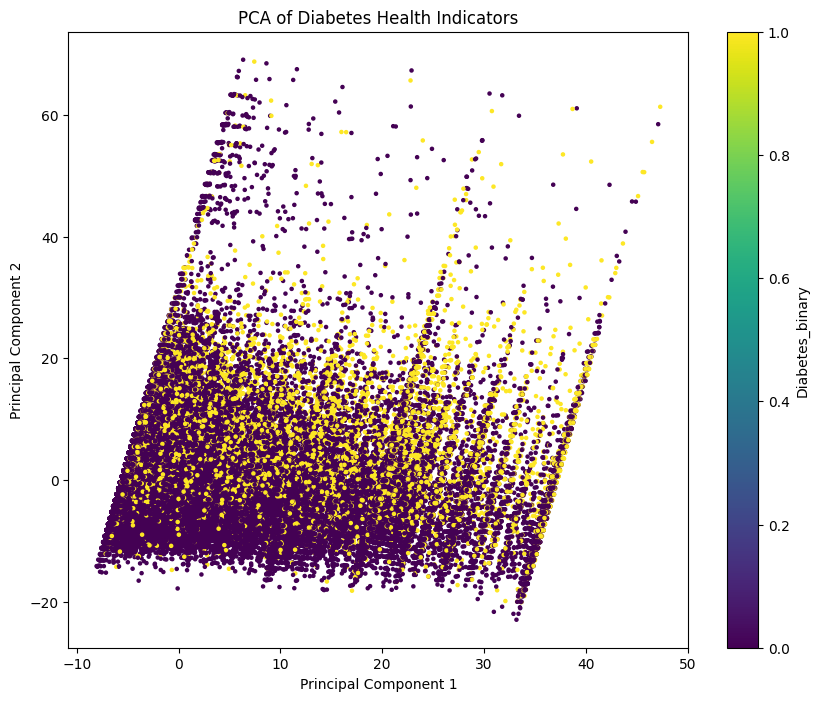

In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.values.flatten(), cmap='viridis', s=5)
plt.title('PCA of Diabetes Health Indicators')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Diabetes_binary')
plt.show()

### t-SNE Analysis

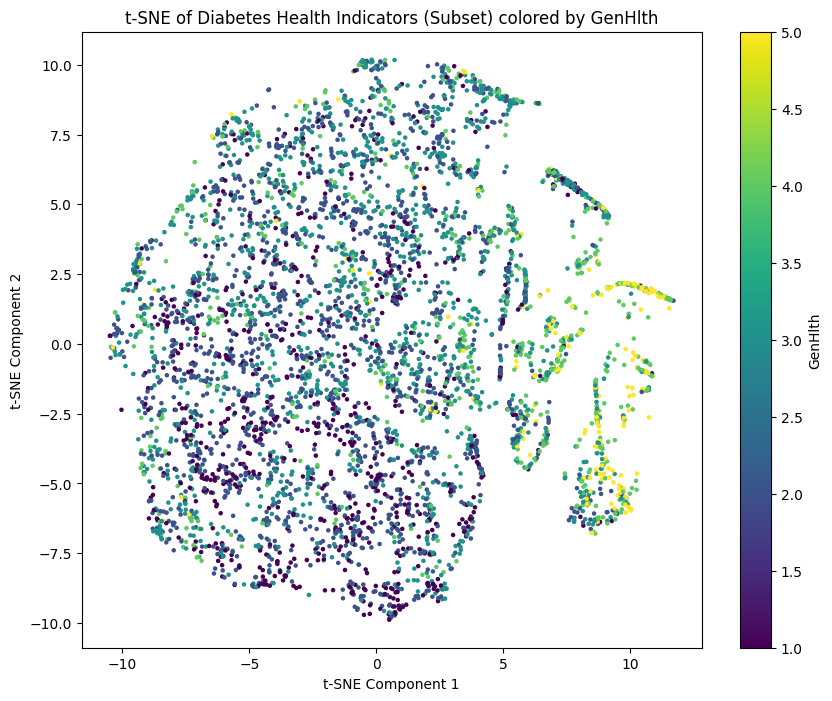

In [23]:
from sklearn.manifold import TSNE

# Apply t-SNE
# Due to the large number of samples, we'll use a smaller subset for t-SNE
# This is a common practice to make t-SNE computationally feasible
subset_size = 5000  # You can adjust this number

# Sample directly from the DataFrame 'df' after duplicate removal
df_subset = df.sample(n=subset_size, random_state=42)

# Separate features and the 'GenHlth' column from the subset
X_subset = df_subset.drop('Diabetes_binary', axis=1) # Assuming 'Diabetes_binary' is the target
genhlth_subset = df_subset['GenHlth']


tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300) # Changed n_iter to max_iter
X_tsne = tsne.fit_transform(X_subset)

# Visualize t-SNE colored by 'GenHlth'
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=genhlth_subset, cmap='viridis', s=5) # Color by GenHlth
plt.title('t-SNE of Diabetes Health Indicators (Subset) colored by GenHlth')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(scatter, label='GenHlth') # Update colorbar label
plt.show()

# Feature Engineering



##Feature Selection
Based on Correlation Analysis and Multi Variate Analysis, We can drop few columns

In [ ]:
# Features to keep based on mutual information scores provided by the user
# features_to_keep = [
#     'HighBP',
#     'CholCheck',
#     'GenHlth',
#     'PhysActivity',
#     'HighChol',
#     'BMI',
#     'Age',
#     'DiffWalk', # Keeping based on previous analyses and reasonable score
#     'HeartDiseaseorAttack', # Keeping based on previous analyses and reasonable score
#     'PhysHlth', # Keeping based on previous analyses and reasonable score
#     'Stroke', # Keeping based on previous analyses and reasonable score
#     'Education', # Keeping based on previous analyses and reasonable score
#     'Income' # Keeping based on previous analyses and reasonable score
# ]


features_to_keep = [
    'HighBP',
    'CholCheck',
    'GenHlth',
    'PhysActivity',
    'HighChol',
    'BMI'
    #,
  #  'AnyHealthcare',
  #  'Fruits',
 #   'Veggies'
]

# Get all current columns in df
all_cols = df.columns.tolist()

# Identify columns to drop (columns in df that are not in features_to_keep, excluding the target)
cols_to_drop = [col for col in all_cols if col not in features_to_keep and col != 'Diabetes_binary']


# Drop the identified columns
df = df.drop(cols_to_drop, axis=1)

## Separate features and target

Separate the features (X) and the target variable (y) from the combined dataframe.


In [ ]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

## Summary:

### Data Analysis Key Findings

*   The features (X) and target variable (y), 'Diabetes\_binary', were successfully separated.
*   The dataset was split into training and testing sets, with `X_train` having a shape of (183579, 42), `X_test` having a shape of (45895, 42), `y_train` having a shape of (183579,), and `y_test` having a shape of (45895,).

### Insights or Next Steps

*   The data is now prepared for training a machine learning model to predict diabetes based on the provided features.


# Train , Test, Validation Data Preparation


Prepare the data for model building by separating features and target, handling categorical variables, and splitting the data into training and testing sets.

## Split the data

Split the dataset into training and testing sets.


In [ ]:
from sklearn.model_selection import train_test_split
#try 70 or 80
# Split the data into training (60%), validation (20%), and testing (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (183579, 6)
Shape of X_val: (22947, 6)
Shape of X_test: (22948, 6)
Shape of y_train: (183579,)
Shape of y_val: (22947,)
Shape of y_test: (22948,)


## Standardize the data
Apply StandardScaler to the training and testing data to standardize the features.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (183579, 6)
Shape of X_test_scaled: (22948, 6)


## SMOTE for  class imbalance

Apply SMOTE to the training data to address the class imbalance in the Diabetes_binary variable.


**Reasoning**:
Import SMOTE and apply it to the scaled training data to address class imbalance.



In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Shape of original X_train:", X_train_scaled.shape)
print("Shape of resampled X_train:", X_train_resampled.shape)
print("Shape of original y_train:", y_train.shape)
print("Shape of resampled y_train:", y_train_resampled.shape)

Shape of original X_train: (183579, 6)
Shape of resampled X_train: (311128, 6)
Shape of original y_train: (183579,)
Shape of resampled y_train: (311128,)


In [ ]:
print("Value counts for y_train_resampled:")
print(y_train_resampled.value_counts())

Value counts for y_train_resampled:
Diabetes_binary
1    155564
0    155564
Name: count, dtype: int64


#Model Training and Validation


A group of models are chosen based on the usecase and trained with Hyperparameter tuning and then best model is selected based on accuracy metrics on test dataset and validation dataset


## Model Selection And Parameters

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report

# Linear Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Tree-Based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Instance-Based Model
from sklearn.neighbors import KNeighborsClassifier

# Gradient Boosting Model
from xgboost import XGBClassifier

# Neural Network Model
from sklearn.neural_network import MLPClassifier
from random import randint
from scipy.stats import loguniform


# Split data into training and testing sets

X_train, y_train = X_train_resampled, y_train_resampled



# --- 3. Define All Models and Their Parameter Grids ---
models_and_params = [
    {
        'model': LogisticRegression(max_iter=1000, solver='liblinear'),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l1', 'l2']
        }
    },
    {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [200, 300],
            'max_depth': [10, 20, None],
            'min_samples_leaf': [1, 2]
        }
     }
    ,

    {
        'model': XGBClassifier(eval_metric='logloss'),
        'params': {
            # 'n_estimators': [100, 200],
            # 'learning_rate': [0.05, 0.1],
            # 'max_depth': [3, 5, 7]
            "n_estimators": [200, 300],
            "learning_rate": [1e-1, 2e-1],
            "max_depth": [5, 10],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
            "gamma": [0, 0.2, 0.4],
            "min_child_weight": [1, 6]
            #,
            # 'scale_pos_weight': [len(y_train_resampled[y_train_resampled == 0]) / len(y_train_resampled[y_train_resampled == 1])] # Added scale_pos_weight
        }

    }
    ,

     {
        'model': MLPClassifier(
             solver='adam', # Added solver
             activation='relu', # Added activation
             max_iter=300, # Changed max_iter
             random_state=42,
             early_stopping=True,
             validation_fraction=0.1, # Added validation_fraction
             n_iter_no_change=15 # Changed n_iter_no_change
        ),
        'params': {
            "hidden_layer_sizes": [ (128, 64)], # Kept user's original list
            "activation": ["relu"], # Kept user's original list
            "alpha": [1e-2], # Kept user's original list
            "learning_rate_init": [1e-2], # Kept user's original list
            "batch_size": [512], # Kept user's original list
        }
    }

]

## Training and Hyperparameter Tuning using GridSearch

In [ ]:
#GridSearchCV for Each Model ---
results = []
best_estimator = None
best_accuracy = 0.0
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Starting comprehensive Grid Search for all 6 models using Stratified K-Fold...")

for item in models_and_params:
    model = item['model']
    params = item['params']
    model_name = model.__class__.__name__

    # Using cv=stratified_kfold for Stratified Cross-Validation
    grid_search = GridSearchCV(estimator=model, param_grid=params, cv=stratified_kfold, n_jobs=-1, scoring='f1', verbose=0)
    grid_search.fit(X_train, y_train)

    test_accuracy = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test_scaled))

    results.append({
        'Model': model_name,
        'Best CV Score': grid_search.best_score_,
        'Test Accuracy': test_accuracy,
        'Best Parameters': grid_search.best_params_
    })

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_estimator = grid_search.best_estimator_

    print(f"Finished for {model_name}.")

Starting comprehensive Grid Search for all 6 models using Stratified K-Fold...
Finished for XGBClassifier.
Finished for MLPClassifier.


## Model Test Metrics

In [ ]:
#Test Metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, balanced_accuracy_score, f1_score, recall_score, precision_score

results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', None)

print("\n--- Final Comprehensive Results ---")
print(results_df)


# --- 6. Show Detailed Report for the Best Overall Model ---
print(f"\n--- Best Overall Model: {best_estimator.__class__.__name__} ---")

y_pred = best_estimator.predict(X_test_scaled)
y_pred_proba = best_estimator.predict_proba(X_test_scaled)[:, 1] # Get probabilities for AUC

# Calculate the requested metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)


# Print metrics in the specified order
print("\nModel Metrics on Test Data:")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")


print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_pred))


--- Final Comprehensive Results ---
           Model  Best CV Score  Test Accuracy  \
0  XGBClassifier       0.735682       0.705944   
1  MLPClassifier       0.729351       0.692086   

                                                                                                                             Best Parameters  
0  {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 600, 'subsample': 1.0}  
1                      {'activation': 'relu', 'alpha': 0.01, 'batch_size': 512, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}  

--- Best Overall Model: XGBClassifier ---

Model Metrics on Test Data:
F1 Score: 0.4429
Recall: 0.7462
Precision: 0.3149
Balanced Accuracy: 0.7224
AUC: 0.7898
Accuracy: 0.7059

Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     19354
           1       0.31      0.75      0.44      3594

    a

## Model Validation and Accuracy Metrics

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# --- 5. Display Results in a Table ---
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', None)

print("\n--- Final Comprehensive Results ---")
print(results_df)


# --- 6. Show Detailed Report for the Best Overall Model on Test Data ---
print(f"\n--- Best Overall Model: {best_estimator.__class__.__name__} ---")
print(f"Test Accuracy: {best_accuracy:.4f}")
print("\nClassification Report on Test Data:")
y_pred_test = best_estimator.predict(X_test_scaled)
print(classification_report(y_test, y_pred_test))

# --- 7. Show Detailed Report for the Best Overall Model on Validation Data ---
print(f"\n--- Best Overall Model: {best_estimator.__class__.__name__} ---")
y_pred_val = best_estimator.predict(scaler.transform(X_val)) # Predicting on the scaled validation data
val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nClassification Report on Validation Data:")
print(classification_report(y_val, y_pred_val))


--- Final Comprehensive Results ---
           Model  Best CV Score  Test Accuracy  \
0  XGBClassifier       0.735682       0.705944   
1  MLPClassifier       0.729351       0.692086   

                                                                                                                             Best Parameters  
0  {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 600, 'subsample': 1.0}  
1                      {'activation': 'relu', 'alpha': 0.01, 'batch_size': 512, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}  

--- Best Overall Model: XGBClassifier ---
Test Accuracy: 0.7059

Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     19354
           1       0.31      0.75      0.44      3594

    accuracy                           0.71     22948
   macro avg       0.63      0.72      0.62     22948
weighted 

### Adjusting Classification Threshold

Apply a custom classification threshold to the predicted probabilities to evaluate its impact on minority class precision.

--- Classification Report with Threshold = 0.6 ---
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     19354
           1       0.36      0.63      0.46      3594

    accuracy                           0.77     22948
   macro avg       0.64      0.71      0.65     22948
weighted avg       0.83      0.77      0.79     22948



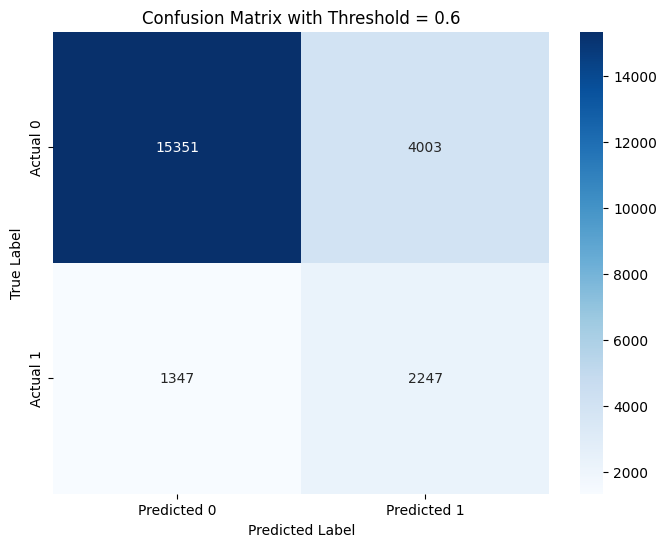

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities for the positive class (Class 1) from the best model
y_pred_proba = best_estimator.predict_proba(X_test_scaled)[:, 1]

# Define a custom threshold (e.g., 0.6)
custom_threshold = 0.6

# Apply the custom threshold to get class predictions
y_pred_thresholded = (y_pred_proba >= custom_threshold).astype(int)

# Evaluate the model with the custom threshold
print(f"--- Classification Report with Threshold = {custom_threshold} ---")
print(classification_report(y_test, y_pred_thresholded))

# Plot the confusion matrix with the custom threshold
cm_thresholded = confusion_matrix(y_test, y_pred_thresholded)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_thresholded, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix with Threshold = {custom_threshold}')
plt.show()

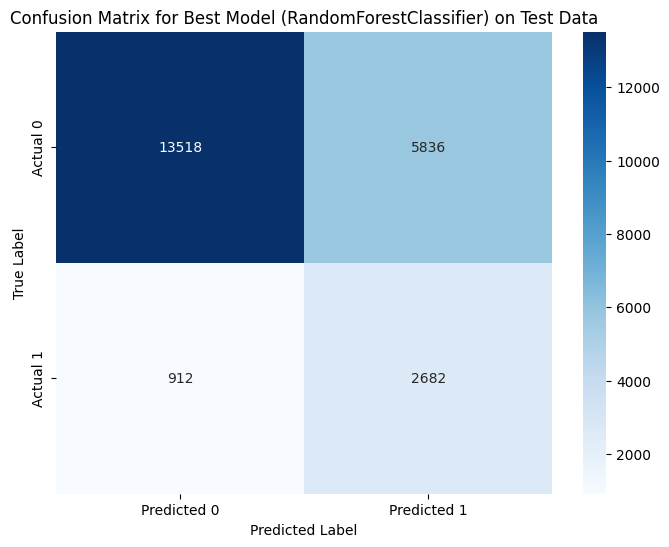

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the best estimator on the scaled test data
y_pred_test = best_estimator.predict(X_test_scaled)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Model (RandomForestClassifier) on Test Data')
plt.show()

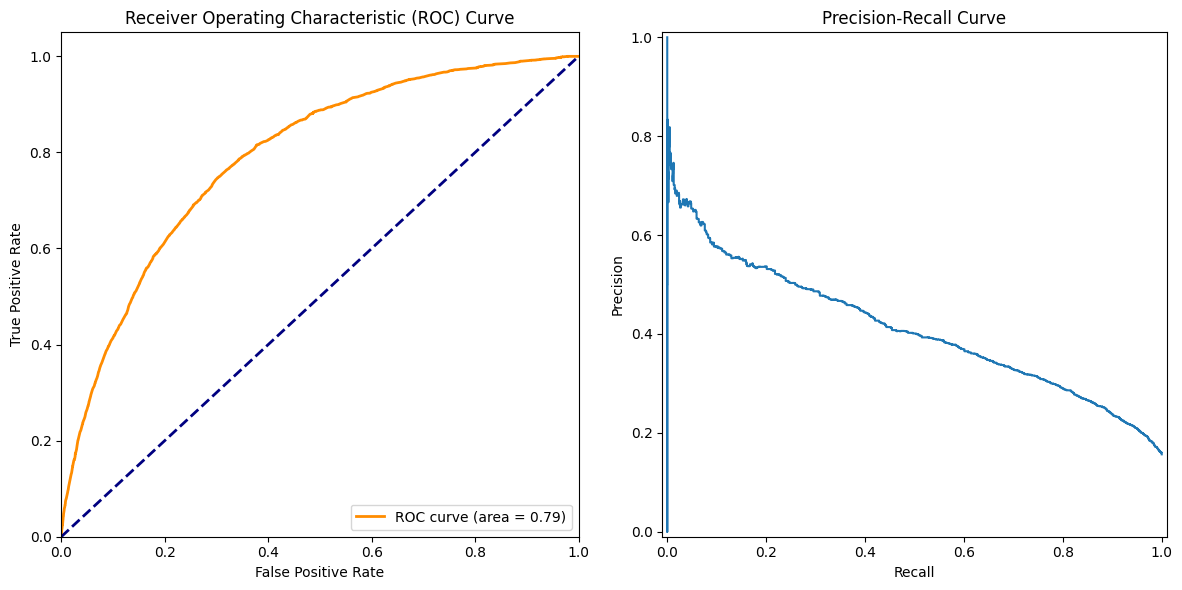


AUC for the best model: 0.7898


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (Class 1)
y_pred_proba = best_estimator.predict_proba(X_test_scaled)[:, 1]

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot(ax=plt.gca())
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

print(f"\nAUC for the best model: {roc_auc:.4f}")

#TODO ADD AP score PR curve , Brier for rel curve

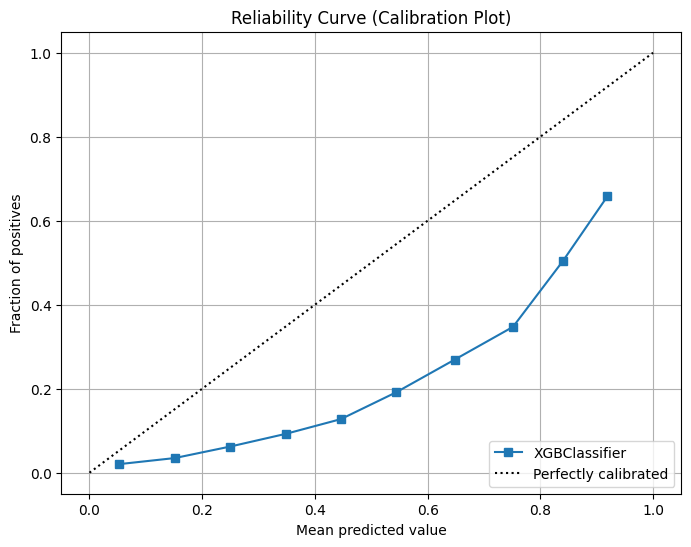

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the positive class (Class 1)
y_pred_proba = best_estimator.predict_proba(X_test_scaled)[:, 1]

# Calculate the calibration curve
# n_bins is the number of bins to use for the calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_pred_proba, n_bins=10)

# Plot the reliability curve
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{best_estimator.__class__.__name__}")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Reliability Curve (Calibration Plot)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

##Feature Importance

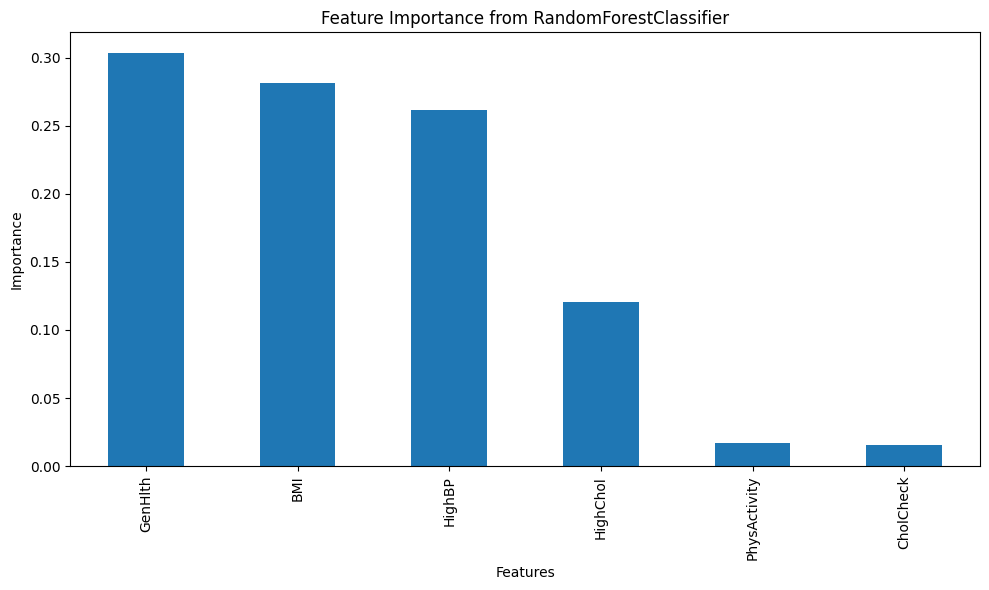

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Assuming X and y are already loaded and preprocessed
# If not, you would load and preprocess your data here

# Initialize and train a RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y.values.ravel())

# Get feature importances
feature_importances = model.feature_importances_

# Create a pandas Series for easier visualization
feature_importance_series = pd.Series(feature_importances, index=X.columns)

# Sort the features by importance
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Visualize the feature importances
plt.figure(figsize=(10, 6))
sorted_feature_importances.plot(kind='bar')
plt.title('Feature Importance from RandomForestClassifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()